# racetraQ 04 — Training the quantum driver

[Notebook 02](02_q_learning_from_scratch.ipynb) built a double-DQN loop;
[notebook 03](03_quantum_circuits_as_q_functions.ipynb) built a quantum
Q-function with fast adjoint gradients. Both Q-functions speak the same
4-method protocol, so training the quantum driver is a one-line swap. This
notebook makes the swap — and then asks how much one training run is worth.

- **Part A — one run, live.** Train the 4-qubit circuit and the small MLP
  baseline on the oval and read the *snapshot eval log*: what gets saved is
  the best snapshot, not the last parameters, and the two can be very
  different drivers.
- **Part B — many seeds.** The same recipes over 8–10 training seeds per
  track, from the study summaries in `data/studies/`: learning curves, first
  clean laps, and how reliable best snapshots and final parameters are.
- **Part C — the stabilisation study.** On gp, the hardest of the three
  tracks, neither agent holds on to what it learns. What was tried, what
  helped a little, and why the circuit and the MLP now train with different
  exploration schedules.
- **Part D — which run becomes the bundled driver.** Ranking, fresh
  re-evaluation, and the `.meta.json` sidecar that records the choice.

An earlier version of this notebook compared the two agents on 4–5 seeds of
July 2026 learning curves and called the result parity. With 8–10 seeds per
recipe and a separate evaluation of every run, that reading does not hold:
**the classical MLP baseline is ahead on most of what is measured below.**
The notebook says so wherever the data do, and says where they do not.

In [1]:
# On Binder (QuBins images) this repo arrives via nbgitpuller without being
# pip-installed; install it from GitHub only if the import fails.
try:
    import racetraq  # noqa: F401
except ImportError:
    %pip install -q git+https://github.com/JanLahmann/racetraQ

import hashlib
import json
import textwrap
import time
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import racetraq
from racetraq.agents.classical import MLPQFunction
from racetraq.agents.quantum import QuantumQFunction
from racetraq.agents.training import DQNTrainer
from racetraq.agents.training.dqn import DEFAULT_EVAL_EPISODES
from racetraq.config import load_config, resolve_training_cfg
from racetraq.env.racing_env import RacingEnv
from racetraq.env.track import Track
from racetraq.train_headless import CleanLapMonitor

# one colour per agent, the same in every figure
COLOR = {"quantum": "#2a78d6", "mlp": "#eb6834"}
LABEL = {"quantum": "quantum circuit", "mlp": "classical MLP"}
C_NEUTRAL = "#8a8a86"
T_START = time.perf_counter()
HEAD = {}  # headline numbers collected along the way for the summary at the end

## Part A — One run, live

### The recipe

`[training]` in `racetraq/config/default.toml` is the base recipe.
`resolve_training_cfg(config, track, agent=...)` merges the track's preset on
top of it and then the agent's own preset — since the audit the two agents
no longer share one recipe (Part C shows the clearest case). On the oval they
share everything except two quantum-only keys:

- `action_gap` — *advantage learning*: the TD target is lowered for every
  action that is not the best one, which widens the gap between the best
  Q-value and the rest and leaves the best action unchanged;
- `act_noise` — while training, the cars and the snapshot evals pick their
  actions from *noisy* readouts, $\langle Z\rangle \to$ attenuation
  $\cdot \langle Z\rangle$ + shot noise, roughly what a device returns.
  TD targets and gradients stay exact.

Both exist so that the driver survives device noise
([notebook 05](05_real_quantum_hardware.ipynb) measures that); Part B shows
what they do on the exact simulator.

In [2]:
TRACK, SEED, EPISODES = "oval", 0, 800  # length and first seed of the oval studies in Part B

config = load_config()
recipe = {agent: resolve_training_cfg(config, TRACK, agent=agent) for agent in ("quantum", "mlp")}
shared = {key: value for key, value in recipe["mlp"].items() if recipe["quantum"].get(key) == value}
print("shared by both agents:")
print(textwrap.fill(", ".join(f"{key} = {value}" for key, value in shared.items()
                              if key not in ("seed", "episodes", "warm_start")),
                    width=96, initial_indent="    ", subsequent_indent="    "))
for agent in recipe:
    own = {key: value for key, value in recipe[agent].items() if key not in shared}
    print(f"only the {LABEL[agent]}: {own or 'nothing'}")
print(f"\n[training] episodes is {shared['episodes']}; this notebook trains {EPISODES}, "
      "as the studies do")

shared by both agents:
    algo = double_dqn, backend = fastsim, replay_size = 10000, batch_size = 32, gamma = 0.98, lr
    = 0.01, target_sync_every = 200, epsilon_start = 1.0, epsilon_end = 0.05,
    epsilon_decay_episodes = 250, n_parallel_envs = 8, bootstrap_truncation = True
only the quantum circuit: {'action_gap': 0.8, 'act_noise': {'attenuation': 0.95, 'shots': 1024}}
only the classical MLP: nothing

[training] episodes is 400; this notebook trains 800, as the studies do


### Train both agents

Environment, replay buffer, double-DQN update, Adam and the $\varepsilon$
schedule are the same code for both; one line builds the Q-function. The
circuit's run is the slow one — every update simulates the circuit. The
cell prints wall-clock and CPU time; on a busy machine the first can be a
multiple of the second.

In [3]:
track = Track.load(TRACK, config["track"]["resample_spacing"])


def train_live(agent):
    '''Train one agent on TRACK with its default recipe; returns what the next cells need.'''
    cfg = dict(recipe[agent], seed=SEED)
    env = RacingEnv(track, config, n_envs=cfg["n_parallel_envs"], seed=SEED)
    monitor = CleanLapMonitor(env)  # notes the first clean lap of the exploring cars
    if agent == "quantum":
        qfunc = QuantumQFunction(config["circuit"], seed=SEED)  # <- the only line that differs
    else:
        qfunc = MLPQFunction(n_features=env.n_features, hidden=8, n_actions=env.n_actions,
                             seed=SEED)
    n_eval = int(cfg.get("eval_episodes", DEFAULT_EVAL_EPISODES))

    def eval_env():  # a fresh env for every snapshot eval: n_eval cars, the same starts each time
        return RacingEnv(track, config, n_envs=n_eval, seed=SEED + 10_000)

    trainer = DQNTrainer(qfunc, monitor, cfg, rng=np.random.default_rng(SEED),
                         env_factory=eval_env)
    cpu_start = time.process_time()
    history = trainer.train(episodes=EPISODES)
    cpu_s = time.process_time() - cpu_start

    best, final = history["best_eval"], history["final_eval"]
    print(f"{LABEL[agent]}: {qfunc.n_params} parameters, {EPISODES} episodes "
          f"in {history['wall_time_s']:.0f} s ({cpu_s:.0f} s of CPU time)")
    if monitor.first_clean_episode is None:
        print("  no clean lap while training")
    else:
        print(f"  first clean lap while training: episode {monitor.first_clean_episode} "
              f"(after {monitor.first_clean_wall_s:.0f} s)")
    print(f"  best snapshot: episode {best['episode']}, "
          f"{best['lapped_episodes']}/{best['eval_episodes']} greedy episodes lapped")
    print(f"  final params:  episode {final['episode']}, "
          f"{final['lapped_episodes']}/{final['eval_episodes']} greedy episodes lapped")
    return {"qfunc": qfunc, "trainer": trainer, "monitor": monitor, "history": history,
            "cpu_s": cpu_s}


runs = {"quantum": train_live("quantum")}

quantum circuit: 56 parameters, 800 episodes in 308 s (158 s of CPU time)
  first clean lap while training: episode 268 (after 33 s)
  best snapshot: episode 750, 12/12 greedy episodes lapped
  final params:  episode 800, 1/12 greedy episodes lapped


In [4]:
runs["mlp"] = train_live("mlp")

classical MLP: 76 parameters, 800 episodes in 146 s (72 s of CPU time)
  first clean lap while training: episode 165 (after 5 s)
  best snapshot: episode 400, 12/12 greedy episodes lapped
  final params:  episode 800, 12/12 greedy episodes lapped


### The snapshot eval log

"First clean lap" above is an exploring car getting round once. Whether the
*policy* can drive is a different question, and the trainer asks it every
`eval_every` = 50 training episodes: it builds a fresh environment of 12
cars, each from its own jittered start, and lets the current parameters drive
one **greedy** episode per car ($\varepsilon = 0$; for the circuit under the
`act_noise` of its recipe). Every eval goes into `history["eval_log"]`.

Snapshots are ranked by (episodes that lapped, mean lap time, mean return) —
reliability first, pace second, so one lucky lap never decides. When
training ends the Q-function is left at the **best snapshot**, and that is
what `train_headless` writes to the weights file. The parameters at the end
of training stay available as `trainer.final_params`.

In [5]:
def nominal(episode, every=50):
    '''Eval episodes are logged as 200, 201, ...: several cars can finish in the same step.'''
    return every * int(round(episode / every))


def stability(log):
    '''Mean lapped fraction over the evals after the first one that lapped (tools/study.py).'''
    first = next((i for i, e in enumerate(log) if e["lapped_episodes"] > 0), None)
    if first is None:
        return 0.0
    later = [e["lapped_episodes"] / e["eval_episodes"] for e in log[first + 1:]]
    return float(np.mean(later)) if later else None


def log_text(entry, best):
    if entry is None:
        return f"{'':<20}"
    lap = f"{entry['mean_lap']:.1f} s" if entry["mean_lap"] is not None else "—"
    kept = "  <- kept" if entry["episode"] == best["episode"] else ""
    return f"{entry['lapped_episodes']:>2}/{entry['eval_episodes']:<4}{lap:<6}{kept:<9}"


logs = {agent: {nominal(e["episode"]): e for e in run["history"]["eval_log"]}
        for agent, run in runs.items()}
print(f"{'':>7}   {LABEL['quantum']:<21}{LABEL['mlp']:<21}")
print(f"{'episode':>7}   {'lapped mean lap':<21}{'lapped mean lap':<21}")
for episode in sorted(set(logs["quantum"]) | set(logs["mlp"])):
    print(f"{episode:>7}   "
          + " ".join(log_text(logs[agent].get(episode), runs[agent]["history"]["best_eval"])
                     for agent in ("quantum", "mlp")))
print()
for agent, run in runs.items():
    log = run["history"]["eval_log"]
    lapping = [e for e in log if e["lapped_episodes"] > 0]
    after = log[log.index(lapping[0]) + 1:] if lapping else []
    dropped = sum(e["lapped_episodes"] < e["eval_episodes"] / 2 for e in after)
    score = stability(log)
    run["stability"] = score
    print(f"{LABEL[agent]}: {len(lapping)} of {len(log)} evals lapped at all; after the first of "
          f"them,\n    {dropped} of {len(after)} evals lapped in fewer than half of their episodes"
          + (f" (stability {score:.2f})" if score is not None else ""))

          quantum circuit      classical MLP        
episode   lapped mean lap      lapped mean lap      
     50    0/12  —                0/12  —              
    100    0/12  —                0/12  —              
    150    3/12  15.6 s           1/12  14.6 s         
    200    0/12  —                0/12  —              
    250    0/12  —                0/12  —              
    300   10/12  14.6 s          10/12  12.8 s         
    350   12/12  14.8 s          12/12  15.3 s         
    400   12/12  13.5 s          12/12  12.7 s  <- kept
    450    0/12  —               12/12  14.7 s         
    500    6/12  14.5 s          12/12  13.3 s         
    550   10/12  13.8 s          12/12  15.1 s         
    600    2/12  14.3 s          12/12  12.9 s         
    650   12/12  12.8 s          12/12  13.3 s         
    700   11/12  12.8 s           9/12  14.0 s         
    750   12/12  12.7 s  <- kept 12/12  14.7 s         
    800    1/12  14.4 s          12/12  14.4 s        

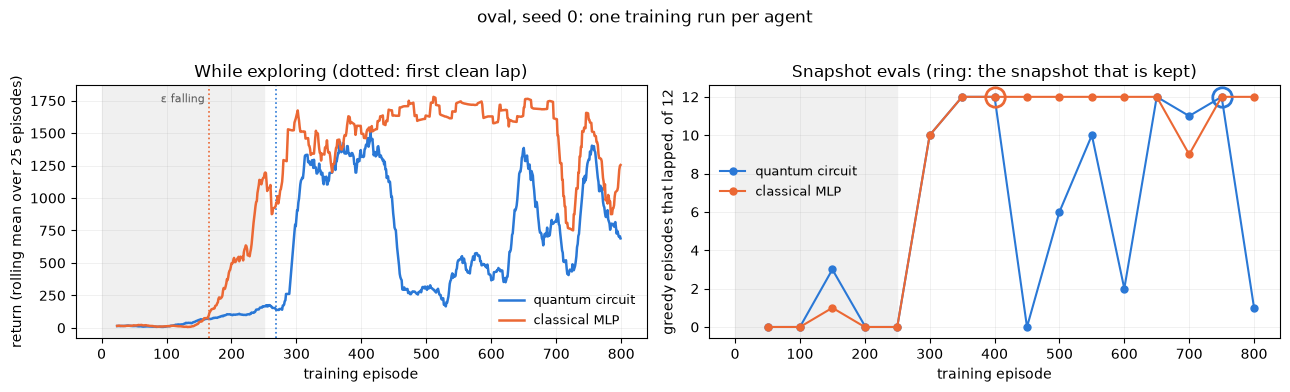

In [6]:
decay = shared["epsilon_decay_episodes"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.8))
for agent, run in runs.items():
    returns = np.array(run["history"]["episode_returns"])
    ax1.plot(np.arange(24, returns.size), np.convolve(returns, np.ones(25) / 25, mode="valid"),
             color=COLOR[agent], lw=1.8, label=LABEL[agent])
    if run["monitor"].first_clean_episode is not None:
        ax1.axvline(run["monitor"].first_clean_episode, color=COLOR[agent], lw=1.2, ls=":")
    log, best = run["history"]["eval_log"], run["history"]["best_eval"]
    ax2.plot([e["episode"] for e in log], [e["lapped_episodes"] for e in log], "o-",
             color=COLOR[agent], lw=1.5, ms=5, label=LABEL[agent])
    ax2.plot(best["episode"], best["lapped_episodes"], "o", ms=14, mfc="none",
             mec=COLOR[agent], mew=2)
for ax in (ax1, ax2):
    ax.axvspan(0, decay, color="0.94", zorder=0)
    ax.set_xlabel("training episode")
    ax.grid(alpha=0.25, lw=0.5)
ax1.set(ylabel="return (rolling mean over 25 episodes)",
        title="While exploring (dotted: first clean lap)")
ax2.set(ylabel=f"greedy episodes that lapped, of {DEFAULT_EVAL_EPISODES}",
        title="Snapshot evals (ring: the snapshot that is kept)")
ax1.text(decay / 2, ax1.get_ylim()[1] * 0.93, "ε falling", ha="center", fontsize=8, color="0.35")
ax1.legend(frameon=False, fontsize=9, loc="lower right")
ax2.legend(frameon=False, fontsize=9, loc="center left", bbox_to_anchor=(0.0, 0.62))
fig.suptitle(f"{TRACK}, seed {SEED}: one training run per agent", y=1.02)
plt.tight_layout()
plt.show()

Read the log before the plot. A policy that laps at one eval is no promise
for the next: the count can fall from 12 of 12 to a few, or to none, 50
episodes later and come back after that. It is not a quirk of the eval —
in the stored run the return of the exploring cars (left) drops at the same
places. The policy itself gets worse and recovers. The *stability* printed
above — the mean lapped fraction over all evals after the first one that
lapped — is the number Part B uses for this; 1 would mean "once it laps, it
keeps lapping".

### Best snapshot against final parameters

The 12 episodes that crowned the best snapshot also *selected* it — the best
of 16 evals is an optimistic estimate. The check that counts uses episodes no
snapshot was chosen on: 36 distinct greedy episodes from other start
positions, with exact Q-values. The studies below call this the *reliability
eval* and run it for the best snapshot and for the final parameters of every
training run.

In [7]:
def reliability(qfunc, params, episodes=36, seed=20_000):
    '''(episodes lapped, mean lap) of `episodes` greedy cars, one episode each, exact Q-values:
    the reliability eval of tools/study.py.'''
    qfunc.set_params(params)
    env = RacingEnv(track, config, n_envs=episodes, seed=seed)
    obs = env.reset()
    finished = np.zeros(episodes, dtype=bool)  # the car's one episode is over (crash, time limit)
    lapped = np.zeros(episodes, dtype=bool)
    prev_lap = np.zeros(episodes, dtype=int)
    lap_times = []
    for _ in range(env.max_decisions + 1):
        obs, _, done, info = env.step(np.argmax(qfunc.q_values(obs), axis=1))
        event = (info["lap"] > prev_lap) & ~finished  # a lap was completed in this step
        lap_times.extend(info["last_lap_time"][event])
        lapped |= event
        finished |= done
        prev_lap = np.where(done, 0, info["lap"])  # a finished car respawns at lap 0
        if finished.all():
            break
    return int(lapped.sum()), (float(np.mean(lap_times)) if lap_times else None)


def lap_text(result):
    count, mean_lap = result
    return f"{count:>2}/36" + (f", mean lap {mean_lap:.1f} s" if mean_lap is not None else "")


print(f"{'':<17}{'best snapshot':<28}{'final params':<28}")
for agent, run in runs.items():
    best_params = run["qfunc"].get_params()  # train() left the Q-function at the best snapshot
    run["reliability"] = [reliability(run["qfunc"], params)
                          for params in (best_params, run["trainer"].final_params)]
    run["qfunc"].set_params(best_params)
    print(f"{LABEL[agent]:<17}{lap_text(run['reliability'][0]):<28}"
          f"{lap_text(run['reliability'][1]):<28}")

                 best snapshot               final params                


quantum circuit  36/36, mean lap 12.7 s       3/36, mean lap 13.9 s      


classical MLP    36/36, mean lap 12.7 s      36/36, mean lap 14.4 s      


Whatever the two rows show in your run — in the stored outputs the circuit's
final parameters are a much worse driver than its best snapshot, and the
MLP's are not — it is **one seed**. A tidy log proves as little as a ragged
one. RL is seed-sensitive, and how sensitive is itself something to measure.

## Part B — Many seeds

`tools/study.py` trains a grid of (recipe variant × seed), one process per
run, and afterwards puts every run's best snapshot *and* its final
parameters through the 36-episode reliability eval of Part A.
`tools/export_study.py` condenses a study into `data/studies/<name>/`:
`report.json` (statistics per variant) and `cells.json` (one record per run:
the eval log, both reliability evals, the first clean lap). The runs
themselves — weights and full logs — are not in the repository.

Three statistics over seeds, following Agarwal et al. (NeurIPS 2021; see
`docs/SCIENCE.md`):

- the **interquartile mean** (IQM): the mean of the middle half of the seeds
  — less swayed by one lucky or unlucky seed than the mean, less wasteful
  than the median;
- a **95 % percentile-bootstrap interval** around it (the seeds resampled
  2000 times);
- to compare two recipes, the **probability of improvement**: the chance
  that a random seed of one beats a random seed of the other (0.5 = no
  difference), again with a bootstrap interval. An interval entirely on one
  side of 0.5 is the bar for calling a difference supported.

With 8–10 seeds these intervals are wide, and they understate the
uncertainty somewhat. The cell loads the summaries, defines the three
statistics, and checks them against the numbers `study.py` wrote.

(To run a study of your own — it is resumable, one cell per process:
`python tools/study.py run --out DIR --agent quantum --track oval --seeds 0-7
--variant base --variant mlp:agent=mlp`, then `python tools/study.py report
DIR`.)

In [8]:
REPO = next((base for base in [Path.cwd(), *Path.cwd().parents]
             if (base / "data" / "studies").is_dir()), None)
RAW = "https://raw.githubusercontent.com/JanLahmann/racetraQ/main/data/studies"
print("study summaries:", "data/studies of this checkout" if REPO
      else f"{RAW} (no checkout found)")
_loaded = {}


def study_json(study, name):
    '''data/studies/<study>/<name>: from the checkout, else from the repository on GitHub.'''
    if (study, name) not in _loaded:
        if REPO is not None:
            text = (REPO / "data" / "studies" / study / name).read_text(encoding="utf-8")
        else:
            try:
                with urllib.request.urlopen(f"{RAW}/{study}/{name}") as response:
                    text = response.read().decode("utf-8")
            except OSError as exc:  # no network, or the summaries are not on that branch
                raise FileNotFoundError(
                    f"data/studies/{study}/{name}: not next to this notebook and not fetchable "
                    f"from {RAW}; run the notebook from a clone of the repository") from exc
        _loaded[study, name] = json.loads(text)
    return _loaded[study, name]


def cells(study, variant):
    '''The training runs of one variant, sorted by seed.'''
    return sorted((cell for cell in study_json(study, "cells.json") if cell["variant"] == variant),
                  key=lambda cell: cell["seed"])


def variant_report(study, variant):
    return study_json(study, "report.json")["variants"][variant]


N_BOOT = 2000


def iqm(values, axis=0):
    '''Interquartile mean along `axis`: a quarter of the sample is dropped at each end (a value
    straddling a quartile counts with the part of it that lies inside).'''
    x = np.moveaxis(np.sort(np.asarray(values, dtype=float), axis=axis), axis, -1)
    n = x.shape[-1]
    whole, part = n // 4, 0.25 * n - n // 4
    weight = np.ones(n)
    weight[:whole] = 0.0
    weight[n - whole:] = 0.0
    weight[whole] -= part
    weight[n - whole - 1] -= part
    return x @ weight / (0.5 * n)


def bootstrap(values, statistic=iqm):
    '''(estimate, low, high) over seeds (axis 0): the 95 % percentile bootstrap of study.py.'''
    v = np.asarray(values, dtype=float)
    rng = np.random.default_rng(0)
    draws = v[rng.integers(0, v.shape[0], size=(N_BOOT, v.shape[0]))]
    low, high = np.percentile(statistic(draws, axis=1), [2.5, 97.5], axis=0)
    return statistic(v, axis=0), low, high


def p_better(a, b, seed=0):
    '''(P, low, high): the chance that a random seed of `a` beats a random seed of `b`
    (larger = better, ties count half), with its bootstrap interval; `seed` is the random
    seed of the bootstrap itself (0 in study.py).'''
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)

    def prob(x, y):
        diff = x[..., :, None] - y[..., None, :]
        wins = (diff > 0).sum(axis=(-2, -1)) + 0.5 * (diff == 0).sum(axis=(-2, -1))
        return wins / (a.size * b.size)

    rng = np.random.default_rng(seed)
    boot = prob(a[rng.integers(0, a.size, size=(N_BOOT, a.size))],
                b[rng.integers(0, b.size, size=(N_BOOT, b.size))])
    low, high = np.percentile(boot, [2.5, 97.5])
    return float(prob(a, b)), float(low), float(high)


def seed_values(study, variant, key):
    '''One value per seed from the report (None where a seed has none, e.g. it never lapped).'''
    return [seed[key] for seed in variant_report(study, variant)["per_seed"]]


# the check: recompute every stability interval and comparison of the gp study
gp_report = study_json("gp_4q", "report.json")
checked = 0
for name, variant in gp_report["variants"].items():
    values = [v for v in seed_values("gp_4q", name, "stability") if v is not None]
    want = variant["metrics"]["stability"]["iqm"]
    assert np.allclose(bootstrap(values), [want["value"], want["ci_low"], want["ci_high"]])
    if "vs_baseline" in variant:
        base = [v for v in seed_values("gp_4q", gp_report["baseline"], "stability")
                if v is not None]
        want = variant["vs_baseline"]["stability"]
        assert np.allclose(p_better(values, base),
                           [want["p_improvement"], want["ci_low"], want["ci_high"]])
    checked += 1
print(f"IQM, interval and probability of improvement reproduce the report for {checked} "
      "variants of the gp study")

study summaries: data/studies of this checkout
IQM, interval and probability of improvement reproduce the report for 29 variants of the gp study


### Which runs are "the default recipe"

The recipes that `resolve_training_cfg` resolves today were not one study
but the outcome of several. Per track, the cell lists the study variant that
*is* today's default for each agent, and three reference variants: the
recipe before the audit for both agents, and — on oval and chicane — the
circuit with exact acting, i.e. without `action_gap` and `act_noise`.

One asymmetry to keep in mind: the circuit's oval and chicane runs act under
emulated device noise in their *in-training* evals (that is the recipe); the
MLP's evals are exact. The 36-episode reliability evals are exact for
everyone.

In [9]:
DEFAULT = {  # today's default recipe: track -> agent -> (study, variant)
    "oval": {"quantum": ("robust_oval_4q", "gap8an"), "mlp": ("oval_4q", "mlp_trunc")},
    "chicane": {"quantum": ("robust_chicane_4q", "gap8an"), "mlp": ("chicane_4q", "mlp_trunc")},
    "gp": {"quantum": ("gp_4q", "eps30_trunc"), "mlp": ("gp_4q", "mlp_trunc")},
}
REFERENCE = {  # for comparison: track -> [(label, study, variant)]
    "oval": [("quantum, exact acting", "oval_4q", "trunc"),
             ("quantum, pre-audit", "oval_4q", "base"), ("mlp, pre-audit", "oval_4q", "mlp")],
    "chicane": [("quantum, exact acting", "chicane_4q", "trunc"),
                ("quantum, pre-audit", "chicane_4q", "base"),
                ("mlp, pre-audit", "chicane_4q", "mlp")],
    "gp": [("quantum, pre-audit", "gp_4q", "base"), ("mlp, pre-audit", "gp_4q", "mlp")],
}


def table_rows(track):
    return [(f"{agent}, default", *DEFAULT[track][agent]) for agent in ("quantum", "mlp")] \
        + REFERENCE[track]


def changes(study, variant):
    '''What the variant overrides, as recorded in the study report.'''
    overrides = variant_report(study, variant)["recipe"]["overrides"]
    text = ", ".join(o.removeprefix("training.").replace("bootstrap_truncation=true", "truncation")
                     .replace('"', "") for o in overrides)
    return text or "—"


print(f"{'':<25}{'study / variant':<32}{'seeds':>6}{'episodes':>10}   "
      "overrides of the pre-audit recipe")
for track_name in DEFAULT:
    print(track_name)
    for label, study, variant in table_rows(track_name):
        runs_of = cells(study, variant)
        print(f"  {label:<23}{study + ' / ' + variant:<32}{len(runs_of):>6}"
              f"{runs_of[0]['episodes']:>10}   {changes(study, variant)}")
print("\ntruncation = bootstrap_truncation=true: the 60 s time limit is not a terminal state")

# is Part A's live run one of these runs?
for agent, run in runs.items():
    twin = next((c for c in cells(*DEFAULT[TRACK][agent]) if c["seed"] == SEED), None)
    same = twin is not None and (
        [(e["episode"], e["lapped_episodes"]) for e in twin["eval_log"]]
        == [(e["episode"], e["lapped_episodes"]) for e in run["history"]["eval_log"]])
    print(f"Part A's {LABEL[agent]} run has the same eval log as seed {SEED} of the study: {same}")

                         study / variant                  seeds  episodes   overrides of the pre-audit recipe
oval
  quantum, default       robust_oval_4q / gap8an             10       800   truncation, action_gap=0.8, act_noise={attenuation=0.95,shots=1024}
  mlp, default           oval_4q / mlp_trunc                  8       800   truncation
  quantum, exact acting  oval_4q / trunc                      8       800   truncation
  quantum, pre-audit     oval_4q / base                       8       800   —
  mlp, pre-audit         oval_4q / mlp                        8       800   —
chicane
  quantum, default       robust_chicane_4q / gap8an          10       800   truncation, action_gap=0.8, act_noise={attenuation=0.95,shots=1024}
  mlp, default           chicane_4q / mlp_trunc               8       800   truncation
  quantum, exact acting  chicane_4q / trunc                   8       800   truncation
  quantum, pre-audit     chicane_4q / base                    8       800   —
  mlp, 

  quantum, default       gp_4q / eps30_trunc                 10      3000   epsilon_end=0.30, truncation
  mlp, default           gp_4q / mlp_trunc                   10      3000   truncation
  quantum, pre-audit     gp_4q / base                        10      3000   —
  mlp, pre-audit         gp_4q / mlp                         10      3000   —

truncation = bootstrap_truncation=true: the 60 s time limit is not a terminal state
Part A's quantum circuit run has the same eval log as seed 0 of the study: True
Part A's classical MLP run has the same eval log as seed 0 of the study: True


The live runs of Part A use the same code, recipe and seed as the first run
of each oval study, so on the same platform they retrace it (the cell says
whether they did here; floating-point differences between platforms can
break the match, and then the live run is simply one more seed).

### Learning curves

Greedy lapped fraction of the snapshot evals against training episode: IQM
over seeds, with the bootstrap band. On gp the 60 evals of a run are
averaged in a moving window of five (250 training episodes) first — most
single gp evals lap in none of their 12 episodes (the cell prints how many),
and the curve of a middle half of such values would show little but jumps.
The thin lines on the oval are Part A's two live runs.

gp, quantum circuit: 435 of 600 single evals lapped in none of their 12 episodes, 27 in all 12
gp, classical MLP: 500 of 600 single evals lapped in none of their 12 episodes, 12 in all 12


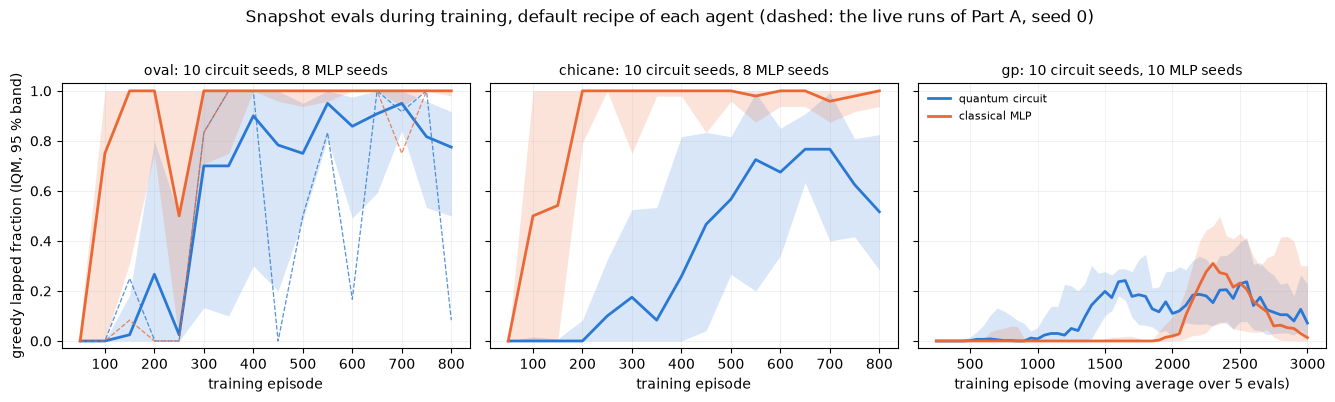

In [10]:
def eval_curve(runs_of):
    '''(episode grid, lapped fraction per seed and eval) of a variant's snapshot evals.'''
    rows = [{nominal(e["episode"]): e["lapped_episodes"] / e["eval_episodes"]
             for e in run["eval_log"]} for run in runs_of]
    grid = sorted(set.intersection(*(set(row) for row in rows)))
    return np.array(grid), np.array([[row[g] for g in grid] for row in rows])


def windowed(grid, frac, window):
    '''Trailing moving average over `window` evals, per seed.'''
    if window == 1:
        return grid, frac
    kernel = np.ones(window) / window
    return grid[window - 1:], np.stack([np.convolve(row, kernel, mode="valid") for row in frac])


WINDOW = {"oval": 1, "chicane": 1, "gp": 5}
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9), sharey=True)
for ax, (track_name, pair) in zip(axes, DEFAULT.items(), strict=True):
    seeds = []
    for agent in ("quantum", "mlp"):
        runs_of = cells(*pair[agent])
        seeds.append(f"{len(runs_of)} {'MLP' if agent == 'mlp' else 'circuit'} seeds")
        x, frac = windowed(*eval_curve(runs_of), WINDOW[track_name])
        if WINDOW[track_name] > 1:  # why a window: what the single evals look like here
            single = np.array([e["lapped_episodes"] for run in runs_of for e in run["eval_log"]])
            n_eval = runs_of[0]["eval_log"][0]["eval_episodes"]
            print(f"{track_name}, {LABEL[agent]}: {int((single == 0).sum())} of {single.size} "
                  f"single evals lapped in none of their {n_eval} episodes, "
                  f"{int((single == n_eval).sum())} in all {n_eval}")
        mid, low, high = bootstrap(frac)
        ax.fill_between(x, low, high, color=COLOR[agent], alpha=0.18, lw=0)
        ax.plot(x, mid, color=COLOR[agent], lw=2, label=LABEL[agent])
        if track_name == TRACK:
            log = runs[agent]["history"]["eval_log"]
            ax.plot([e["episode"] for e in log],
                    [e["lapped_episodes"] / e["eval_episodes"] for e in log],
                    color=COLOR[agent], lw=0.9, ls="--", alpha=0.8)
    ax.set_title(f"{track_name}: {', '.join(seeds)}", fontsize=10)
    ax.set_xlabel("training episode" if WINDOW[track_name] == 1 else
                  f"training episode (moving average over {WINDOW[track_name]} evals)")
    ax.set_ylim(-0.03, 1.03)
    ax.grid(alpha=0.25, lw=0.5)
axes[0].set_ylabel("greedy lapped fraction (IQM, 95 % band)")
axes[-1].legend(fontsize=8, frameon=False, loc="upper left")  # the one panel with free space
fig.suptitle("Snapshot evals during training, default recipe of each agent "
             f"(dashed: the live runs of Part A, seed {SEED})", y=1.02)
plt.tight_layout()
plt.show()

### The numbers behind the curves

Per track and variant, IQM over seeds with the 95 % interval, from
`report.json`:

- **first clean lap** — the training episode in which an exploring car first
  completed a lap (over the seeds that ever did);
- **to 50 %** — training episodes until half of *all* seeds have had an eval
  that lapped in at least half of its episodes, so seeds that never get
  there count against a recipe ("—" = fewer than half do);
- **stability** — as in Part A;
- **best snapshot / final params** — lapped fraction in the 36-episode
  reliability eval;
- **mean lap** — of the best snapshot, over the seeds whose best snapshot
  lapped at all.

Below the table: the probability that a random MLP seed beats a random
circuit seed, default recipe against default recipe. In the two
time-to-event columns a seed that never got there counts as later than any
that did (*to 50 %* uses each seed's own first eval that lapped in at least
half of its episodes); *mean lap* is compared over the seeds that have one,
as in the table.

In [11]:
def ci(stat, fmt):
    '''"IQM [low, high]" of one metric of the report.'''
    value = stat["iqm"]
    if value["value"] is None or stat["n"] == 0:
        return "—"
    if value["ci_low"] is None:
        return f"{value['value']:{fmt}} [—]"
    return f"{value['value']:{fmt}} [{value['ci_low']:{fmt}}, {value['ci_high']:{fmt}}]"


print(f"{'':<25}{'seeds':>5}{'first clean lap':>20}{'to 50 %':>9}{'stability':>20}"
      f"{'best snapshot':>20}{'final params':>20}{'mean lap (s)':>20}")
for track_name in DEFAULT:
    print(track_name)
    for label, study, variant in table_rows(track_name):
        rep = variant_report(study, variant)
        m = rep["metrics"]
        half = rep["sample_complexity"]["episodes_to_50"]["episodes_half_of_seeds"]
        print(f"  {label:<23}{rep['n_seeds']:>5}{ci(m['first_clean_episode'], '.0f'):>20}"
              f"{half if half is not None else '—':>9}{ci(m['stability'], '.2f'):>20}"
              f"{ci(m['best_lapped_frac'], '.2f'):>20}{ci(m['final_lapped_frac'], '.2f'):>20}"
              f"{ci(m['best_mean_lap'], '.1f'):>20}")

NEVER = 1e9  # "never" in a time-to-event metric: later than every seed that got there
CENSORED = ("first_clean_episode", "episodes_to_50")  # where a seed without a value counts as last
COMPARE = [("first clean lap", "first_clean_episode", -1), ("to 50 %", "episodes_to_50", -1),
           ("stability", "stability", +1),
           ("best snapshot", "best_lapped_frac", +1), ("final params", "final_lapped_frac", +1),
           ("mean lap", "best_mean_lap", -1)]
print("\nP(a random MLP seed beats a random circuit seed) [95 % interval]; "
      "* = interval entirely on one side of 0.5")
print(f"{'':<10}" + "".join(f"{title:>24}" for title, _, _ in COMPARE))
HEAD["p_mlp"] = {}
for track_name, pair in DEFAULT.items():
    line = f"{track_name:<10}"
    for title, key, sign in COMPARE:
        mlp, quantum = ([-NEVER if v is None else sign * v for v in seed_values(*pair[a], key)
                         if v is not None or key in CENSORED] for a in ("mlp", "quantum"))
        p, low, high = p_better(mlp, quantum)
        HEAD["p_mlp"][track_name, title] = (p, low, high)
        mark = "*" if low > 0.5 or high < 0.5 else " "
        line += f"{f'{p:.2f} [{low:.2f}, {high:.2f}]{mark}':>24}"
    print(line)

print("\nP(a random seed of today's default recipe is more stable than a random seed of the "
      "pre-audit recipe) [95 % interval]")
for track_name, pair in DEFAULT.items():
    line = f"{track_name:<10}"
    for agent in ("quantum", "mlp"):
        before = next((study, variant) for label, study, variant in REFERENCE[track_name]
                      if label == f"{agent}, pre-audit")
        now, then = ([v for v in seed_values(*lane, "stability") if v is not None]
                     for lane in (pair[agent], before))
        p, low, high = p_better(now, then)
        mark = "*" if low > 0.5 or high < 0.5 else " "
        line += f"{LABEL[agent] + ':':>20} {p:.2f} [{low:.2f}, {high:.2f}]{mark}"
    print(line)

                         seeds     first clean lap  to 50 %           stability       best snapshot        final params        mean lap (s)
oval
  quantum, default          10      264 [236, 341]      250   0.75 [0.52, 0.92]   1.00 [0.94, 1.00]   0.80 [0.47, 0.99]   13.7 [13.2, 14.1]
  mlp, default               8      153 [134, 168]      100   0.94 [0.87, 0.99]   1.00 [1.00, 1.00]   1.00 [0.98, 1.00]   12.9 [12.6, 13.2]
  quantum, exact acting      8      294 [238, 369]      350   0.69 [0.57, 0.75]   1.00 [0.98, 1.00]   0.84 [0.57, 0.97]   13.9 [13.3, 14.4]
  quantum, pre-audit         8      294 [238, 369]      350   0.58 [0.49, 0.71]   1.00 [0.98, 1.00]   0.52 [0.01, 1.00]   13.8 [13.1, 14.3]
  mlp, pre-audit             8      153 [134, 168]      100   0.92 [0.86, 0.96]   1.00 [1.00, 1.00]   1.00 [0.87, 1.00]   13.3 [12.9, 13.7]
chicane
  quantum, default          10      355 [247, 478]      300   0.63 [0.49, 0.73]   1.00 [0.87, 1.00]   0.63 [0.39, 0.88]   13.6 [13.0, 14.3]
  mlp, 

Track by track:

- **oval.** The MLP is ahead in every column but one — the best snapshots
  of both agents lap in all of their episodes — and five of the six
  comparisons are supported. It drives its first clean lap after 153
  training episodes where the circuit needs 264, it holds on to lapping
  better (stability 0.94 against 0.75), its final parameters drive as well
  as its best snapshot, and its best snapshots are faster (mean lap 12.9 s
  against 13.7 s).
- **chicane.** The same order for learning speed and stability — 0.97
  against 0.63 is the widest stability gap in the table. Lap times are the
  exception: the circuit's best snapshots average 13.6 s, the MLP's 13.9 s,
  a difference these seeds do not resolve.
- **gp.** A different picture. The circuit's greedy policy gets there
  *earlier*: half of its seeds have a mostly-lapping eval by episode 1100,
  the MLP's by 2150, and this difference is resolved (0.09 [0.00, 0.27] for
  the MLP being the earlier one; the pre-audit rows, where both agents share
  one schedule, show the same order: 800 against 2250). More of the
  circuit's best snapshots also lap reliably (0.96 against 0.74), a trend
  that ten seeds do not resolve. Pace is resolved the other way: the MLP's
  laps are about ten seconds faster (25.4 s against 35.0 s). And neither
  agent keeps what it learned: stability is below 0.2 for both, and the
  final parameters of both lap in almost none of their episodes.

The reference rows and the last lines of the output say what the recipe
changes since the audit bought. For the circuit, the stability estimate rose
on every track against the pre-audit recipe (0.58 → 0.75, 0.36 → 0.63,
0.08 → 0.17), but only on the chicane is that improvement supported
(0.87 [0.68, 1.00]); on the oval it is not (0.66 [0.39, 0.90]), and on gp the
interval reaches just below 0.5 (0.75 [0.49, 0.95]; Part C). Acting under
noise with an action gap shows no cost on the exact simulator — the default
rows are at least as stable as "exact acting" (the intervals overlap). For
the MLP, bootstrapping through the time limit changes little on oval and
chicane (0.92 → 0.94 and 0.92 → 0.97, the second a small but supported gain);
on gp nothing can be resolved, and its final-parameter column even looks
worse with it (0.01 against 0.17, both intervals wide).

oval     classical MLP    earliest   130, IQM   153, latest   186
         quantum circuit  earliest   184, IQM   264, latest   475
         circuit seeds earlier than the latest MLP seed: 1 of 10; the circuit's seeds span 5.2 times the range of the MLP's
chicane  classical MLP    earliest   138, IQM   183, latest   218
         quantum circuit  earliest   212, IQM   355, latest   604
         circuit seeds earlier than the latest MLP seed: 1 of 10; the circuit's seeds span 4.9 times the range of the MLP's
gp       classical MLP    earliest  1628, IQM  1868, latest  2424; 1 of 10 seeds never
         quantum circuit  earliest  1495, IQM  1768, latest  2535
         circuit seeds earlier than the latest MLP seed: 9 of 10; the circuit's seeds span 1.3 times the range of the MLP's


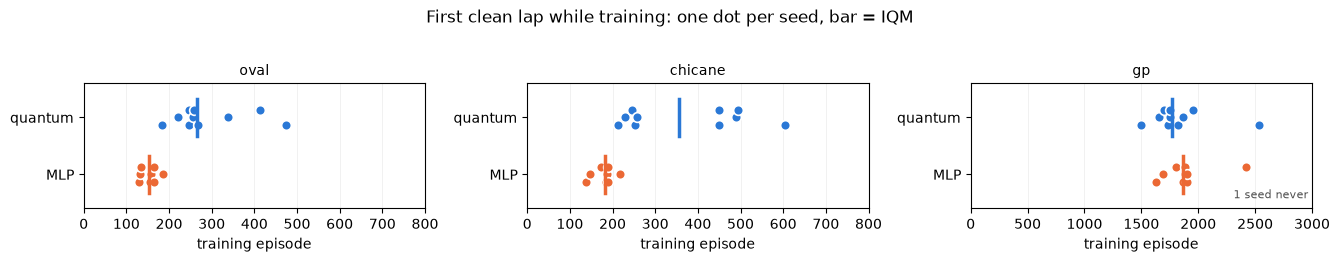

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 2.5))
for ax, (track_name, pair) in zip(axes, DEFAULT.items(), strict=True):
    total = cells(*pair["quantum"])[0]["episodes"]
    reached_by = {}
    for row, agent in enumerate(("mlp", "quantum")):
        first = [run["first_clean_episode"] for run in cells(*pair[agent])]
        reached = reached_by[agent] = np.sort([f for f in first if f is not None]).astype(float)
        ax.plot(reached, row + 0.13 * (np.arange(reached.size) % 3 - 1), "o",  # staggered
                color=COLOR[agent], ms=7, mec="white", mew=1.2)
        ax.plot([iqm(reached)] * 2, [row - 0.33, row + 0.33], color=COLOR[agent], lw=2.5)
        never = len(first) - reached.size
        if never:
            ax.text(total * 0.99, row - 0.42, f"{never} seed never", ha="right", fontsize=8,
                    color="0.3")
        print(f"{track_name if row == 0 else '':<9}{LABEL[agent]:<17}earliest "
              f"{reached.min():>5.0f}, IQM {iqm(reached):>5.0f}, latest {reached.max():>5.0f}"
              + (f"; {never} of {len(first)} seeds never" if never else ""))
    earlier = int((reached_by["quantum"] < reached_by["mlp"].max()).sum())
    print(f"{'':<9}circuit seeds earlier than the latest MLP seed: {earlier} of "
          f"{reached_by['quantum'].size}; the circuit's seeds span "
          f"{np.ptp(reached_by['quantum']) / np.ptp(reached_by['mlp']):.1f} times the range "
          "of the MLP's")
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["MLP", "quantum"])
    ax.set_ylim(-0.6, 1.6)
    ax.set_xlim(0, total)
    ax.set_xlabel("training episode")
    ax.set_title(track_name, fontsize=10)
    ax.grid(axis="x", alpha=0.25, lw=0.5)
fig.suptitle("First clean lap while training: one dot per seed, bar = IQM", y=1.03)
plt.tight_layout()
plt.show()

A first clean lap is the earliest sign of learning — one exploring car got
round once — and says nothing about pace or reliability. It is also one of
the numbers the earlier version of this notebook compared the agents on. On
oval and chicane the slowest MLP seed is ahead of all but one of the
circuit's, and the circuit's seeds are spread over a range about five times
as wide. On gp the two overlap; the circuit's IQM is about 100 episodes
earlier, which these seeds do not resolve, and one MLP seed never laps at
all.

                            seeds   best snapshot laps >= 18/36   final params lap >= 18/36   final params lap 0/36
oval      quantum circuit      10                            10                           7                       0
          classical MLP         8                             8                           8                       0
chicane   quantum circuit      10                             9                           8                       1
          classical MLP         8                             8                           8                       0
gp        quantum circuit      10                            10                           0                       4
          classical MLP        10                             7                           2                       7


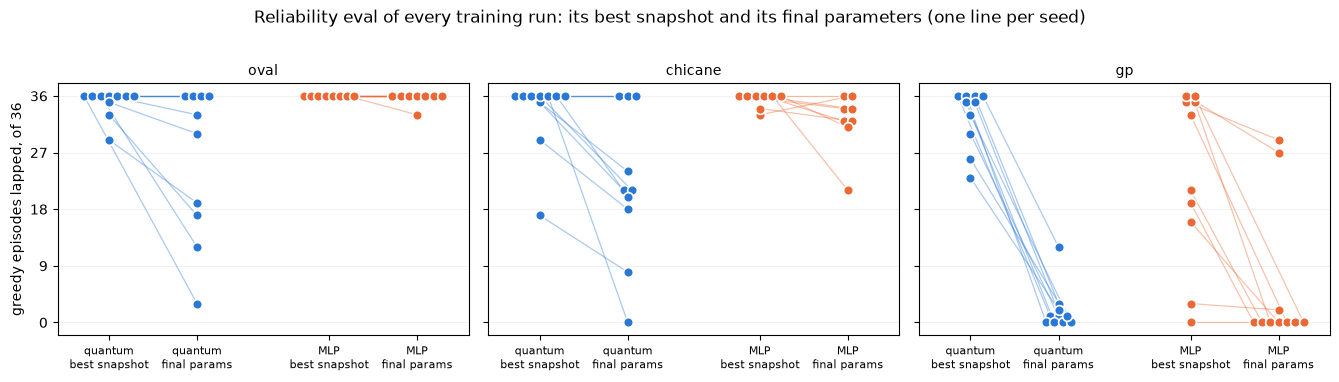


Part A's circuit run: final params lapped 3/36; the 10 seeds of the study: [3, 12, 17, 19, 30, 33, 36, 36, 36, 36]


In [13]:
def spread(values, width=0.34):
    '''Horizontal offsets that pull equal values apart so every seed stays visible.'''
    values = np.asarray(values)
    offsets = np.zeros(values.size)
    for value in np.unique(values):
        same = np.flatnonzero(values == value)
        offsets[same] = np.linspace(-1, 1, same.size) * width * min(1, (same.size - 1) / 6)
    return offsets


fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.7), sharey=True)
print(f"{'':<27}{'seeds':>6}{'best snapshot laps >= 18/36':>30}"
      f"{'final params lap >= 18/36':>28}{'final params lap 0/36':>24}")
HEAD["final_half"] = {}
for ax, (track_name, pair) in zip(axes, DEFAULT.items(), strict=True):
    for column, agent in enumerate(("quantum", "mlp")):
        runs_of = cells(*pair[agent])
        best = np.array([run["best_snapshot_eval"]["lapped_episodes"] for run in runs_of])
        final = np.array([run["final_params_eval"]["lapped_episodes"] for run in runs_of])
        x_best, x_final = 3 * column + spread(best), 3 * column + 1.2 + spread(final)
        for i in range(best.size):
            ax.plot([x_best[i], x_final[i]], [best[i], final[i]], color=COLOR[agent], lw=0.9,
                    alpha=0.4)
        ax.plot(x_best, best, "o", color=COLOR[agent], ms=7, mec="white", mew=1.2)
        ax.plot(x_final, final, "o", color=COLOR[agent], ms=7, mec="white", mew=1.2)
        HEAD["final_half"][track_name, agent] = (int((final >= 18).sum()), final.size)
        print(f"{track_name if column == 0 else '':<10}{LABEL[agent]:<17}{best.size:>6}"
              f"{int((best >= 18).sum()):>30}{int((final >= 18).sum()):>28}"
              f"{int((final == 0).sum()):>24}")
    ax.set_xticks([0, 1.2, 3, 4.2])
    ax.set_xticklabels(["quantum\nbest snapshot", "quantum\nfinal params",
                        "MLP\nbest snapshot", "MLP\nfinal params"], fontsize=8)
    ax.set_xlim(-0.7, 4.9)
    ax.set_ylim(-2, 38)
    ax.set_yticks([0, 9, 18, 27, 36])
    ax.set_title(track_name, fontsize=10)
    ax.grid(axis="y", alpha=0.25, lw=0.5)
axes[0].set_ylabel("greedy episodes lapped, of 36")
fig.suptitle("Reliability eval of every training run: its best snapshot and its final "
             "parameters (one line per seed)", y=1.02)
plt.tight_layout()
plt.show()

live = runs["quantum"]["reliability"][1][0]
others = [run["final_params_eval"]["lapped_episodes"] for run in cells(*DEFAULT[TRACK]["quantum"])]
print(f"\nPart A's circuit run: final params lapped {live}/36; the {len(others)} seeds of the "
      f"study: {sorted(others)}")

This is what "best snapshot" hides. One line per training run, from the
snapshot it would ship (left) to where its training actually ended (right):

- The MLP's lines on oval and chicane are nearly flat. Where its training
  stops hardly matters.
- The circuit's fan out. On the oval 7 of 10 seeds end with parameters that
  still lap in at least half of the 36 episodes, on the chicane 8 of 10.
  Seed 0 — the seed of Part A — has the lowest final count of the ten oval
  seeds: the live run was the worst case, not the typical one.
- On gp nearly every line of either agent falls to the floor: 0 of 10
  circuit seeds and 2 of 10 MLP seeds end training with parameters that lap
  in half of their episodes.

A weights file from this trainer is therefore a **peak, not a plateau**.
The snapshot is a real policy, and Part D re-checks it on fresh episodes;
but "the agent learned gp" overstates what the optimiser holds on to. The
accurate sentence is: at some point in training the agent could drive gp,
and that point was kept.

## Part C — The stabilisation study on gp

gp has a hairpin that must be braked for; the oval and the chicane can be
driven flat out. Under the recipe the project used until the audit
(`base`: $\varepsilon$ from 1.0 to 0.05 over the first 2000 of 3000
episodes, the time limit treated as a terminal state) the picture of Part B
is at its worst: best snapshots that lap, final parameters that do not.

The study asked which change to the recipe makes the learned policy
*stay*. It trained 29 variants, 202 runs in all: 6 seeds each, 10 for the
baselines and for the candidates for a new default. The table lists what
each variant changes (the overrides recorded in the report), and per
variant: how many seeds have a best snapshot that laps in at least half of
its 36 episodes, the IQM of the two reliability evals and of the stability,
and the probability that a random seed of the variant is more stable than a
random seed of `base`.

In [14]:
gp_recipe = {agent: resolve_training_cfg(config, "gp", agent=agent)
             for agent in ("quantum", "mlp")}
for agent, gp_cfg in gp_recipe.items():
    print(f"today's gp recipe, {LABEL[agent]}: ε {gp_cfg['epsilon_start']} -> "
          f"{gp_cfg['epsilon_end']} over the first {gp_cfg['epsilon_decay_episodes']} of "
          f"{gp_cfg['episodes']} episodes, bootstrap_truncation = "
          f"{gp_cfg['bootstrap_truncation']}")
print(f"the study's baseline `base` (pre-audit): the same schedule down to "
      f"{config['training']['epsilon_end']}, the time limit a terminal state\n")

GROUPS = [
    ("the pre-audit recipe", ["base"]),
    ("standard DQN stabilisers", ["trunc", "huber", "soft", "lrdecay", "lrgroups", "rscale",
                                  "nobonus", "stable"]),
    ("replay, batch, target sync, step size, discount",
     ["replay200k", "replay200k_trunc", "replay200k_b128", "b128", "sync1000", "lowlr",
      "gamma98"]),
    ("exploration floor (epsilon_end; 0.05 in base)",
     ["eps15", "eps15_trunc", "eps30", "eps30_trunc", "eps30_trunc_b128"]),
    ("a bigger circuit", ["L6", "L8", "q6"]),
    ("the MLP", ["mlp", "mlp_trunc", "mlp_replay200k", "mlp_h32", "mlp_eps30_trunc"]),
]
assert sorted(name for _, names in GROUPS for name in names) == sorted(gp_report["variants"])


def describe(name):
    recipe_of = gp_report["variants"][name]["recipe"]
    parts = [f"profile {recipe_of['profile']}"] if recipe_of["profile"] else []
    return ", ".join(parts + ([changes("gp_4q", name)] if recipe_of["overrides"] else [])) or "—"


print(f"{'variant':<18}{'params':>6}{'seeds':>6}{'>= half':>9}{'best':>6}{'final':>7}"
      f"{'stability':>20}{'P(more stable than base)':>27}   what it changes")
supported, worse, forest = [], [], []
for title, names in GROUPS:
    print(f"-- {title}")
    for name in names:
        rep = gp_report["variants"][name]
        m = rep["metrics"]
        versus = rep.get("vs_baseline", {}).get("stability")
        if versus:
            mark = "*" if versus["ci_low"] > 0.5 else "-" if versus["ci_high"] < 0.5 else " "
            p_text = (f"{versus['p_improvement']:.2f} [{versus['ci_low']:.2f}, "
                      f"{versus['ci_high']:.2f}]{mark}")
            forest.append((name, rep["recipe"]["agent"], versus))
            if mark == "*":
                supported.append(name)
            elif mark == "-":
                worse.append(name)
        else:
            p_text = "(baseline) "
        print(f"{name:<18}{rep['n_params']:>6}{rep['n_seeds']:>6}"
              f"{rep['reliable_seeds']:>6}/{rep['n_seeds']:<2}"
              f"{m['best_lapped_frac']['iqm']['value']:>6.2f}"
              f"{m['final_lapped_frac']['iqm']['value']:>7.2f}"
              f"{ci(m['stability'], '.2f'):>20}{p_text:>27}   {describe(name)}")
print("\n* interval entirely above 0.5 (supported improvement), - entirely below; "
      "truncation = bootstrap_truncation=true")
by_agent = [v["recipe"]["agent"] for v in gp_report["variants"].values()]
print(f"{len(by_agent)} variants ({by_agent.count('quantum')} circuit, "
      f"{by_agent.count('mlp')} MLP), "
      f"{sum(v['n_seeds'] for v in gp_report['variants'].values())} training runs, "
      f"{len(forest)} comparisons with base; "
      f"supported improvements over base: {', '.join(supported) or 'none'}; "
      f"supported as worse: {', '.join(worse) or 'none'}")
HEAD["gp_variants"] = len(gp_report["variants"])
HEAD["gp_supported"] = supported

# how firm is a "supported" mark? the same intervals under other random seeds of the bootstrap
base_stability = seed_values("gp_4q", gp_report["baseline"], "stability")
print("\nlower end of the interval under ten other bootstrap seeds (the report used seed 0):")
for name in [*supported, "eps30_trunc"]:
    lows = [p_better(seed_values("gp_4q", name, "stability"), base_stability, seed=s)[1]
            for s in range(1, 11)]
    print(f"  {name:<12}{min(lows):.2f} to {max(lows):.2f}; above 0.5 for "
          f"{sum(low > 0.5 for low in lows)} of {len(lows)} seeds")

today's gp recipe, quantum circuit: ε 1.0 -> 0.3 over the first 2000 of 3000 episodes, bootstrap_truncation = True
today's gp recipe, classical MLP: ε 1.0 -> 0.05 over the first 2000 of 3000 episodes, bootstrap_truncation = True
the study's baseline `base` (pre-audit): the same schedule down to 0.05, the time limit a terminal state

variant           params seeds  >= half  best  final           stability   P(more stable than base)   what it changes
-- the pre-audit recipe
base                  56    10     9/10  0.89   0.00   0.08 [0.04, 0.15]                (baseline)    —
-- standard DQN stabilisers
trunc                 56     6     6/6   0.94   0.06   0.13 [0.04, 0.47]         0.57 [0.25, 0.87]    truncation
huber                 56     6     4/6   0.78   0.00   0.03 [0.01, 0.10]         0.25 [0.02, 0.55]    loss=huber
soft                  56     6     6/6   0.92   0.00   0.06 [0.04, 0.18]         0.47 [0.17, 0.77]    target_update=soft
lrdecay               56     6     4/6   0.6

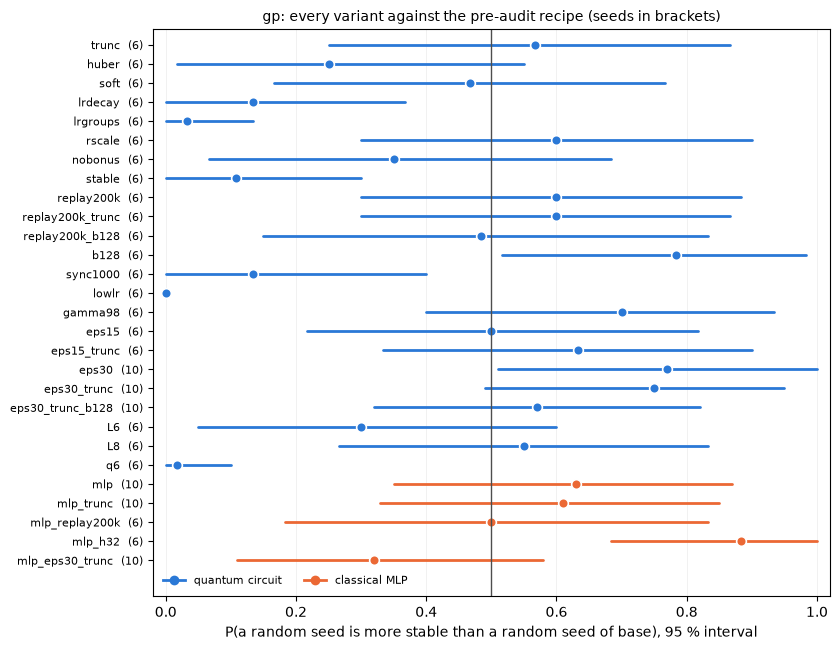

In [15]:
fig, ax = plt.subplots(figsize=(8.5, 6.6))
for row, (_, agent, versus) in enumerate(forest):
    ax.plot([versus["ci_low"], versus["ci_high"]], [row, row], color=COLOR[agent], lw=2,
            solid_capstyle="round")
    ax.plot(versus["p_improvement"], row, "o", color=COLOR[agent], ms=7, mec="white", mew=1.2)
ax.axvline(0.5, color="0.3", lw=1)
ax.set_yticks(range(len(forest)))
ax.set_yticklabels([f"{name}  ({gp_report['variants'][name]['n_seeds']})" for name, _, _ in forest],
                   fontsize=8)
ax.set_ylim(len(forest) + 0.9, -0.8)  # top to bottom; room for the legend under the last row
ax.set_xlim(-0.02, 1.02)
ax.set_xlabel("P(a random seed is more stable than a random seed of base), 95 % interval")
ax.set_title("gp: every variant against the pre-audit recipe (seeds in brackets)", fontsize=10)
ax.grid(axis="x", alpha=0.25, lw=0.5)
ax.legend(handles=[plt.Line2D([], [], color=COLOR[a], marker="o", lw=2, label=LABEL[a])
                   for a in ("quantum", "mlp")], frameon=False, fontsize=8, loc="lower left",
          ncol=2)
plt.tight_layout()
plt.show()

Read the table for what is *not* in it.

- **None of the standard stabilisers helps.** Huber loss, soft target
  updates, learning-rate decay, per-group learning rates, scaled rewards,
  dropping the lap bonuses, and a combination (`stable`): stability stays
  where it was or gets worse. Six variants in the table are supported as
  *worse* than the baseline.
- **Replay, batch size, target sync, step size, discount:** nothing clear
  either. `b128` clears the bar on its 6 seeds, barely (lower end 0.52; 0.50
  to 0.53 under other random seeds of the bootstrap itself — the last lines
  of the output). Combined with the changes that were adopted and run on 10
  seeds (`eps30_trunc_b128`) it does not — stability 0.12, and only 7 of 10
  seeds with a reliable best snapshot — so it was not adopted.
- **More circuit does not help.** Six or eight blocks at 4 qubits are not
  more stable, and the 6-qubit profile does not learn gp at all under this
  recipe (0 of 6 seeds).
- **A higher exploration floor is the one lever that seems to move the
  circuit — just.** `eps30`: stability 0.18 against 0.08, probability of
  improvement 0.77 [0.51, 1.00]; under ten other bootstrap seeds the lower
  end is 0.50 to 0.52, above 0.5 for 6 of them. With truncation on top
  (`eps30_trunc`, today's default): 0.17, and 0.75 [0.49, 0.95] — an interval
  that includes 0.5 under every bootstrap seed tried. By the bar of Part B
  the adopted recipe is therefore *not* a supported improvement of the
  stability score. It is a modest effect at the edge of what ten seeds can
  show, and in a table of 28 comparisons an interval or two clears 0.5 by
  chance alone. The case for the floor rests on the diagnostic below as much
  as on this table.
- **The final-params column stays near zero for every variant.** The
  highest value is 0.31. No recipe here makes the end of training a good
  place to stop.
- **The most stable variant is a classical one:** the MLP with 32 hidden
  units (292 parameters), at 0.24.

Why the floor? The next figure is the diagnostic that led to it.

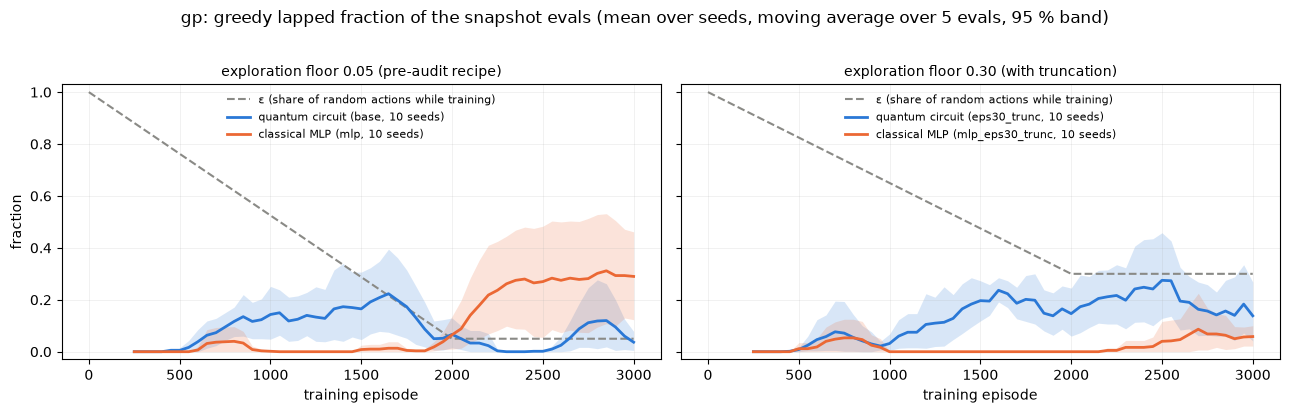

base             highest point of the curve: 0.22 at episode 1650 (ε = 0.22 there)
mlp              highest point of the curve: 0.31 at episode 2850 (ε = 0.05 there)
eps30_trunc      highest point of the curve: 0.27 at episode 2500 (ε = 0.30 there)
mlp_eps30_trunc  highest point of the curve: 0.09 at episode 2700 (ε = 0.30 there)

the same curves from episode 2000 on (ε at its floor)
base             between 0.00 and 0.12; last point (episode 3000): 0.04
mlp              between 0.07 and 0.31; last point (episode 3000): 0.29
eps30_trunc      between 0.14 and 0.27; last point (episode 3000): 0.14
mlp_eps30_trunc  between 0.00 and 0.09; last point (episode 3000): 0.06

mean greedy lapped fraction of the snapshot evals, over seeds [95 % interval]
                                   seeds        episodes 1300-2000        episodes 2050-3000
circuit, floor 0.05                   10         0.14 [0.05, 0.24]         0.04 [0.01, 0.08]
circuit, floor 0.30                   10         0.18 [0.15,

In [16]:
def epsilon(episodes, end, decay=gp_recipe["quantum"]["epsilon_decay_episodes"], start=1.0):
    return start + (end - start) * np.clip(np.asarray(episodes) / decay, 0.0, 1.0)


PANELS = [("exploration floor 0.05 (pre-audit recipe)", 0.05, {"quantum": "base", "mlp": "mlp"}),
          ("exploration floor 0.30 (with truncation)", 0.30,
           {"quantum": "eps30_trunc", "mlp": "mlp_eps30_trunc"})]
peaks, after = {}, {}
decay_gp = gp_recipe["quantum"]["epsilon_decay_episodes"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, (title, floor, variants) in zip(axes, PANELS, strict=True):
    episodes = np.arange(0, 3001, 10)
    ax.plot(episodes, epsilon(episodes, floor), color=C_NEUTRAL, lw=1.5, ls="--",
            label="ε (share of random actions while training)")
    for agent, variant in variants.items():
        runs_of = cells("gp_4q", variant)
        x, frac = windowed(*eval_curve(runs_of), 5)
        mid, low, high = bootstrap(frac, statistic=np.mean)
        ax.fill_between(x, low, high, color=COLOR[agent], alpha=0.18, lw=0)
        ax.plot(x, mid, color=COLOR[agent], lw=2,
                label=f"{LABEL[agent]} ({variant}, {len(runs_of)} seeds)")
        peaks[variant] = (int(x[np.argmax(mid)]), float(mid.max()), floor)
        at_floor = mid[x >= decay_gp]
        after[variant] = (float(at_floor.min()), float(at_floor.max()), float(mid[-1]), int(x[-1]))
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("training episode")
    ax.set_ylim(-0.03, 1.03)
    ax.grid(alpha=0.25, lw=0.5)
    ax.legend(fontsize=8, frameon=False, loc="upper center")
axes[0].set_ylabel("fraction")
fig.suptitle("gp: greedy lapped fraction of the snapshot evals (mean over seeds, moving average "
             "over 5 evals, 95 % band)", y=1.02)
plt.tight_layout()
plt.show()

for variant, (episode, height, floor) in peaks.items():
    print(f"{variant:<16} highest point of the curve: {height:.2f} at episode {episode} "
          f"(ε = {epsilon(episode, floor):.2f} there)")
print(f"\nthe same curves from episode {decay_gp} on (ε at its floor)")
for variant, (lowest, highest, last, last_episode) in after.items():
    print(f"{variant:<16} between {lowest:.2f} and {highest:.2f}; last point (episode "
          f"{last_episode}): {last:.2f}")

PHASES = [("episodes 1300-2000", 1300, 2000), ("episodes 2050-3000", 2050, 3000)]
print(f"\nmean greedy lapped fraction of the snapshot evals, over seeds [95 % interval]\n"
      f"{'':<34}{'seeds':>6}" + "".join(f"{title:>26}" for title, _, _ in PHASES))
HEAD["gp_phase"] = {}
for label, variant in [("circuit, floor 0.05", "base"), ("circuit, floor 0.30", "eps30"),
                       ("circuit, floor 0.30 + truncation", "eps30_trunc"),
                       ("MLP, floor 0.05", "mlp"), ("MLP, floor 0.05 + truncation", "mlp_trunc"),
                       ("MLP, floor 0.30 + truncation", "mlp_eps30_trunc")]:
    grid, frac = eval_curve(cells("gp_4q", variant))
    line = f"{label:<34}{frac.shape[0]:>6}"
    for title, start, stop in PHASES:
        mid, low, high = bootstrap(frac[:, (grid >= start) & (grid <= stop)].mean(axis=1),
                                   statistic=np.mean)
        HEAD["gp_phase"][variant, title] = float(mid)
        line += f"{f'{mid:.2f} [{low:.2f}, {high:.2f}]':>26}"
    print(line)

**Left: the pre-audit schedule.** The circuit's greedy driving improves
*while training is still exploring heavily*. Its curve peaks around episode
1650, when about a fifth of the actions in training are still random, and
falls away as $\varepsilon$ reaches its floor of 0.05: 0.14 of the eval
episodes lapped over episodes 1300–2000, 0.04 after episode 2050 (with a
partial and temporary recovery near the end). The MLP does the
opposite — next to nothing until $\varepsilon$ is low, then a climb
(0.03 → 0.27).

Why the circuit loses its policy once exploration stops is not established.
The obvious suspect, a replay buffer too small to remember varied
experience, did not confirm: a buffer 20 times larger (`replay200k` in the
table) made no measurable difference.

(The two windows, before and after $\varepsilon$ reaches its floor at
episode 2000, were drawn after looking at these curves. The numbers describe
the figure; they are not a test of a hypothesis fixed in advance.)

**Right: the consequence, a floor of 0.30.** The circuit's curve no longer
collapses (0.18 before episode 2000, 0.20 after). It stays at a level where
roughly a fifth of the greedy eval episodes lap — between 0.14 and 0.27 from
episode 2000 on, and at the low end of that range when training stops — "no
late collapse", which is not the same as "stable". The MLP under the same
floor hardly learns gp at all: 0.04 after episode 2050, against 0.22 with its
own floor.

In [17]:
def lapped_list(values):
    return " ".join(f"{v:>2}" for v in values)


print("gp, best snapshot of every run: greedy episodes lapped, of 36, in the reliability eval\n")
print(f"{'':<51}{'seeds':<8}{'lapped of 36, per seed':<33}{'>= 18'}")
ROWS = [("circuit, 4 qubits, floor 0.05 + truncation", "gp_4q", "trunc"),
        ("circuit, 4 qubits, floor 0.30 + truncation", "gp_4q", "eps30_trunc"),
        ("MLP, floor 0.05 + truncation", "gp_4q", "mlp_trunc"),
        ("MLP, floor 0.30 + truncation", "gp_4q", "mlp_eps30_trunc"),
        ("circuit, 10 qubits, 4 blocks, floor 0.30 + trunc.", "gp_q10feat", "L4"),
        ("circuit, 10 qubits, 6 blocks, floor 0.30 + trunc.", "gp_q10feat", "L6")]
HEAD["gp_half"] = {}
for label, study, variant in ROWS:
    runs_of = cells(study, variant)
    lapped = [run["best_snapshot_eval"]["lapped_episodes"] for run in runs_of]
    seeds = f"{runs_of[0]['seed']}-{runs_of[-1]['seed']}"
    HEAD["gp_half"][study, variant] = (sum(v >= 18 for v in lapped), len(lapped))
    print(f"{label:<51}{seeds:<8}{lapped_list(lapped):<33}"
          f"{sum(v >= 18 for v in lapped)} of {len(lapped)}")

july = study_json("gp_q10feat_july_recipe", "results.json")
for label, layout in [("circuit, 10 qubits, 4 blocks, July recipe", "base"),
                      ("circuit, 10 qubits, 6 blocks, July recipe", "L6")]:
    runs_of = sorted((r for r in july if r["layout"] == layout), key=lambda r: r["seed"])
    lapped = [r["best_snapshot_36"]["lapped"] for r in runs_of]
    HEAD["gp_half"]["gp_q10feat_july_recipe", layout] = (sum(v >= 18 for v in lapped),
                                                         len(lapped))
    print(f"{label:<51}{', '.join(str(r['seed']) for r in runs_of):<8}{lapped_list(lapped):<33}"
          f"{sum(v >= 18 for v in lapped)} of {len(lapped)}")
print("\n10 qubits: 5 rays + speed + four engineered track features, one feature per qubit.\n"
      "July recipe: floor 0.05, time limit terminal, snapshots chosen on 4 distinct episodes;\n"
      "single runs of the first audit experiment, not a study.py study.")

def late_fraction(variant):
    '''Per seed: mean lapped fraction of the snapshot evals in the late window of the figure.'''
    _, start, stop = PHASES[1]
    grid, frac = eval_curve(cells("gp_4q", variant))
    return frac[:, (grid >= start) & (grid <= stop)].mean(axis=1)


FLOOR_METRICS = [("best snapshot laps", lambda v: seed_values("gp_4q", v, "best_lapped_frac")),
                 (f"lapped, {PHASES[1][0]}", late_fraction),
                 ("stability", lambda v: seed_values("gp_4q", v, "stability"))]
print("\nfloor 0.30 against floor 0.05 within each agent: P(a random seed with the 0.30 floor "
      "beats a random seed\nwith the 0.05 floor) [95 % interval]; * = interval entirely on one "
      "side of 0.5")
print(f"{'':<58}{'seeds':<9}" + "".join(f"{title:>29}" for title, _ in FLOOR_METRICS))
HEAD["gp_floor"] = {}
for label, high_floor, low_floor in [
        ("circuit, the floor alone", "eps30", "base"),
        ("circuit, both with truncation", "eps30_trunc", "trunc"),
        ("MLP, both with truncation", "mlp_eps30_trunc", "mlp_trunc")]:
    sizes = f"{len(cells('gp_4q', high_floor))} v {len(cells('gp_4q', low_floor))}"
    line = f"{label + ' (' + high_floor + ' / ' + low_floor + ')':<58}{sizes:<9}"
    for title, per_seed in FLOOR_METRICS:
        p, low, high = p_better(per_seed(high_floor), per_seed(low_floor))
        HEAD["gp_floor"][label, title] = (p, low, high)
        mark = "*" if low > 0.5 or high < 0.5 else " "
        line += f"{f'{p:.2f} [{low:.2f}, {high:.2f}]{mark}':>29}"
    print(line)
print("upper end of the MLP's intervals under ten other bootstrap seeds:")
for title, per_seed in FLOOR_METRICS:
    highs = [p_better(per_seed("mlp_eps30_trunc"), per_seed("mlp_trunc"), seed=s)[2]
             for s in range(1, 11)]
    print(f"  {title:<30}{min(highs):.2f} to {max(highs):.2f}; below 0.5 for "
          f"{sum(high < 0.5 for high in highs)} of {len(highs)} seeds")

print("\nwhat the 0.30 floor does to the 4-qubit circuit on each track (both with truncation), "
      "IQM [95 % interval]")
print(f"{'':<10}{'stability, floor 0.05':>24}{'floor 0.30':>20}{'mean lap (s), floor 0.05':>28}"
      f"{'floor 0.30':>20}")
for track_name in DEFAULT:
    low_floor, high_floor = (variant_report(f"{track_name}_4q", v)["metrics"]
                             for v in ("trunc", "eps30_trunc"))
    print(f"{track_name:<10}{ci(low_floor['stability'], '.2f'):>24}"
          f"{ci(high_floor['stability'], '.2f'):>20}{ci(low_floor['best_mean_lap'], '.1f'):>28}"
          f"{ci(high_floor['best_mean_lap'], '.1f'):>20}")

gp, best snapshot of every run: greedy episodes lapped, of 36, in the reliability eval

                                                   seeds   lapped of 36, per seed           >= 18
circuit, 4 qubits, floor 0.05 + truncation         0-5     35 35 25 36 34 30                6 of 6
circuit, 4 qubits, floor 0.30 + truncation         0-9     36 36 30 36 35 35 33 36 23 26    10 of 10
MLP, floor 0.05 + truncation                       0-9     19 21 35 35 16 33 36  0 36  3    7 of 10
MLP, floor 0.30 + truncation                       0-9      0 27  3  0  4  1 29  0 36 16    3 of 10
circuit, 10 qubits, 4 blocks, floor 0.30 + trunc.  0-2      0  4  0                         0 of 3
circuit, 10 qubits, 6 blocks, floor 0.30 + trunc.  0-2      2  7  5                         0 of 3
circuit, 10 qubits, 4 blocks, July recipe          0, 42    6 24                            1 of 2
circuit, 10 qubits, 6 blocks, July recipe          0, 42   16 17                            0 of 2

10 qubits: 5 rays

**The agents lean towards opposite schedules.** With the 0.30 floor the
4-qubit circuit's best snapshot laps in at least half of its episodes at 10
of 10 seeds; the MLP's at 3 of 10, against 7 of 10 with the 0.05 floor. The
second block of the output puts intervals on that, floor against floor
within each agent. For the circuit the floor shows in the late phase of
training (0.91 [0.75, 1.00] with the floor as the only change) and not in
the best snapshots, which were reliable under either floor (6 of 6 with 0.05
and truncation). For the MLP all three estimates point against the floor
(0.26 to 0.28), and each of the three intervals reaches 0.5 or just beyond,
under every bootstrap seed tried: a consistent trend on ten seeds, short of
a supported difference by the bar of Part B. Nothing suggests that the floor
helps the MLP, so it sits in `[training_presets_quantum.gp]` and not in the
track's preset: `resolve_training_cfg(config, "gp", agent="mlp")` keeps 0.05
(the first lines of the output above the variant table).

**It is not even "the circuit's schedule".** The 10-qubit circuit with
engineered features — the configuration of the bundled `quantum_gp_q10` —
fails under the new recipe: none of its 6 runs has a best snapshot that laps
in half of its episodes, the best manages 7 of 36. Under the July recipe its
four single runs lapped in 6 to 24 of 36. That is an observation, not a
controlled comparison: two settings differ (the floor *and* truncation), the
seeds differ, the snapshots were selected differently, and each row is two
or three runs. It is enough to say that the 4-qubit recipe does not carry
over as it stands — which of its two changes is responsible, these runs
cannot say — and `quantum_gp_q10` stays the July driver for now.

**It is a gp recipe.** The last lines of the output show why the floor was
adopted for gp (and combo, which shares the hairpin) only: on oval and
chicane it does not make the circuit more stable, and on the chicane it
costs about two seconds a lap.

What the study shows is narrow: on gp, a 0.30 exploration floor removes
the 4-qubit circuit's late collapse (0.04 → 0.20 of the eval episodes lapped
after episode 2050, intervals apart) without a supported gain in the
stability score. Nothing that was tried makes either agent's training
*converge* to a driver.

## Part D — Which run becomes the bundled driver

The demo ships one weights file per driver, and Part B says what that file
can be: one seed's best snapshot. Since the audit the choice is made by a
tool, `tools/bundle_driver.py`, and written down next to the weights:

1. rank the seeds of a study variant by the study's own 36-episode
   reliability eval of their best snapshots (lapped fraction, then mean lap);
2. re-evaluate the top few on **fresh** episodes — 72 greedy episodes from
   start positions that neither training nor the study's eval ever used —
   and, for the drivers of the hardware demo, on the simulated device;
3. take the best of those, and record candidates, numbers and the recipe's
   spread over all its seeds in the `selection` block of the `.meta.json`
   sidecar.

The sidecar of the default driver, `quantum_oval`:

In [18]:
WEIGHTS = Path(racetraq.__file__).parent / "weights"


def sidecar(name):
    return json.loads((WEIGHTS / f"{name}.meta.json").read_text(encoding="utf-8"))


def spread_text(stat):
    return f"{stat['iqm']:.2f} [{stat['ci_low']:.2f}, {stat['ci_high']:.2f}]"


NAME = f"quantum_{TRACK}"
meta = sidecar(NAME)
selection = meta["selection"]
print(f"{NAME}: study {selection['study']}, variant {selection['variant']}")
print("overrides: " + ", ".join(selection["overrides"]))
print(textwrap.fill("rule: " + selection["rule"], width=100, subsequent_indent="      "))

on_device = "device_eval" in selection
print(f"\n{'seed':>6}{'study eval':>14}{'mean lap':>10}{'fresh eval':>14}{'mean lap':>10}"
      + (f"{'simulated device':>20}" if on_device else ""))
for c in selection["candidates"]:
    device = (f"{c['device_lapped']}/{c['device_episodes']}" if "device_lapped" in c else "—")
    print(f"{c['seed']:>6}{c['study_lapped']:>10}/{c['study_episodes']:<3}"
          f"{c['study_mean_lap']:>8.1f} s{c['fresh_lapped']:>10}/{c['fresh_episodes']:<3}"
          f"{c['fresh_mean_lap']:>8.1f} s" + (f"{device:>20}" if on_device else "")
          + ("   <- chosen" if c["seed"] == selection["chosen_seed"] else ""))

fresh, spread_of = selection["fresh_eval"], selection["seed_spread"]
print(f"\nthe driver: seed {selection['chosen_seed']} of {selection['n_seeds']}; fresh eval "
      f"{fresh['lapped']}/{fresh['episodes']} episodes lapped, mean lap {fresh['mean_lap']:.1f} s, "
      f"best {fresh['best_lap']:.1f} s")
if on_device:
    device = selection["device_eval"]
    print(f"on the simulated device ({device['fake']}, {device['shots']} shots, resilience "
          f"{device['resilience']}): {device['lapped']}/{device['episodes']} episodes lapped")
print(f"the recipe over its {spread_of['n_seeds']} seeds (IQM [95 % interval]):\n"
      f"    best snapshot laps {spread_text(spread_of['best_snapshot_lapped'])}, final params "
      f"{spread_text(spread_of['final_params_lapped'])}, stability "
      f"{spread_text(spread_of['stability'])}")

digest = hashlib.sha256((WEIGHTS / f"{NAME}.npz").read_bytes()).hexdigest()
print(f"\nweights file matches the recorded sha256: {digest == selection['weights_sha256']}")
bundled = np.load(WEIGHTS / f"{NAME}.npz")["params"]
mine = runs["quantum"]["qfunc"].get_params()
if selection["chosen_seed"] == SEED and bundled.shape == mine.shape:
    print(f"the bundled driver is seed {SEED}, the seed of Part A's live run; largest difference "
          f"between\n    its parameters and the live run's best snapshot: "
          f"{np.abs(bundled - mine).max():.1e}")

quantum_oval: study robust_oval, variant gap8an
overrides: training.bootstrap_truncation=true, training.action_gap=0.8, training.act_noise={attenuation=0.95,shots=1024}
rule: seeds ranked by the study's 36-episode reliability eval of the best snapshot (lapped fraction,
      then mean lap); the top 4 re-evaluated on 72 fresh distinct greedy episodes (env seed 31000)
      and the driver chosen by that result (episodes lapped on the simulated device, then lapped
      fraction, then mean lap); the fresh numbers are the ones recorded (they also picked among the
      4 candidates, so a small selection effect remains in them)

  seed    study eval  mean lap    fresh eval  mean lap    simulated device
     0        36/36     12.7 s        72/72     12.7 s                 8/8   <- chosen
     1        36/36     12.8 s        72/72     12.8 s                 8/8
     4        36/36     13.7 s        72/72     13.7 s                 8/8
     9        36/36     13.7 s        72/72     13.7 s  

Three things to notice.

- **The reported numbers are the fresh ones.** The study's eval ranked the
  seeds, so the winner's score in it is biased upwards; 72 episodes it was
  not ranked on are the cleaner estimate. They are not perfectly clean
  either — they picked among the top candidates — and the `rule` says so.
- **For the drivers of the hardware demo the device decides.** Eight
  episodes with every decision evaluated through the noise model of an IBM
  device ([notebook 05](05_real_quantum_hardware.ipynb)) come first in the
  ranking, lapped fraction and pace after.
- **The recipe's spread travels with the driver.** `seed_spread` is the
  Part B statistic of the whole recipe, so a reader of the weights file can
  see that the driver is one of the better seeds of a recipe whose *final*
  parameters are much less dependable — not a typical outcome of pressing
  "train".

In the stored outputs the chosen seed is 0, the run Part A repeated, and the
live run's best snapshot is the bundled driver, parameter for parameter.
(The sidecar names a study by its working directory, e.g. `robust_oval`; the
summary in the repository is `data/studies/robust_oval_4q`.)

The same block for every bundled driver that has been re-selected:

In [19]:
def fresh_text(fresh):
    if "tracks" in fresh:  # a multi-track driver: one fresh eval per track
        return (f"{fresh['lapped']}/{fresh['episodes']}",
                " / ".join(f"{t['mean_lap']:.1f}" for t in fresh["tracks"].values())
                + f" s ({' / '.join(fresh['tracks'])})")
    return f"{fresh['lapped']}/{fresh['episodes']}", f"{fresh['mean_lap']:.1f} s"


chosen, snapshots, unselected = {}, {}, []
for path in sorted(WEIGHTS.glob("*.meta.json")):
    name = path.name.removesuffix(".meta.json")
    meta_of = json.loads(path.read_text(encoding="utf-8"))
    if meta_of.get("selection"):
        chosen[name] = meta_of["selection"]
    elif "_stage" in name or "_warmstart" in name:  # not a driver: see below
        snapshots[name] = meta_of
    else:
        unselected.append(name)

print(f"{'driver':<21}{'study / variant':<27}{'seed':>5}{'of':>4}{'fresh eval':>12}"
      f"{'device':>8}   mean lap")
for name, block in chosen.items():
    lapped, laps = fresh_text(block["fresh_eval"])
    device = block.get("device_eval")
    on_device = f"{device['lapped']}/{device['episodes']}" if device else "—"
    print(f"{name:<21}{block['study'] + ' / ' + block['variant']:<27}{block['chosen_seed']:>5}"
          f"{block['n_seeds']:>4}{lapped:>12}{on_device:>8}   {laps}")
print(f"\ndrivers without a selection block (not re-selected yet): "
      f"{', '.join(unselected) or 'none'}")

# stage and warm-start files: earlier snapshots of one training run, for the demo's evolution
# mode and its warm live-training (tools/make_stages.py); their sidecars record that run
by_run = {}
for meta_of in snapshots.values():
    by_run.setdefault((meta_of.get("run") or {}).get("driver"), []).append(meta_of)
print(f"\n{len(snapshots)} stage and warm-start files, snapshots of a training run:")
for driver, files in by_run.items():
    if driver is None:
        print(f"  {len(files)} files without a recorded run (older files)")
        continue
    run_of = files[0]["run"]
    stages = sorted(m["episodes"] for m in files if "stage" in m)
    warm = sorted(m["episodes"] for m in files if "stage" not in m)
    replayed = all(m["run"].get("reproduces_driver") for m in files)
    print(f"  {driver.removesuffix('.npz'):<17}seed {run_of['seed']}, best snapshot at episode "
          f"{run_of['best_episode']:>4}: stages at episodes {', '.join(map(str, stages))}; "
          f"warm-start checkpoint at {', '.join(map(str, warm)) or '—'}"
          + ("" if replayed else "   (the replay did NOT reproduce the driver)"))

print("\nbundled 4-qubit specialists, fresh eval: circuit against MLP")
HEAD["bundled"] = {}
for track_name in ("oval", "chicane", "gp", "combo"):
    pair = {agent: chosen.get(f"{agent}_{track_name}") for agent in ("quantum", "mlp")}
    if all(pair.values()):
        laps = {agent: block["fresh_eval"]["mean_lap"] for agent, block in pair.items()}
        HEAD["bundled"][track_name] = laps
        faster = min(laps, key=laps.get)
        print(f"  {track_name:<8} circuit {laps['quantum']:.1f} s, MLP {laps['mlp']:.1f} s  ->  "
              f"{LABEL[faster]} faster by {abs(laps['quantum'] - laps['mlp']):.1f} s")

driver               study / variant             seed  of  fresh eval  device   mean lap
mlp_chicane          study_chicane / mlp_trunc      2   8       72/72       —   13.3 s
mlp_combo            combo / mlp_trunc              2  10       72/72       —   36.9 s
mlp_gp               study_gp1 / mlp_trunc          6  10       72/72       —   22.5 s
mlp_oval             study_oval / mlp_trunc         6   8       72/72       —   12.6 s
mlp_pro              pro / pro                      1   3     144/144       —   12.7 / 13.1 / 17.8 / 20.3 s (oval / chicane / gp / combo)
quantum_chicane      robust_chicane / gap8an        7  10       72/72     8/8   12.6 s
quantum_chicane_q10  q10_chicane / L6               2   6       72/72       —   12.6 s
quantum_chicane_q6   q6_chicane / quantum           3   8       72/72       —   12.9 s
quantum_chicane_q8   q8_chicane / L5                3   6       72/72       —   12.6 s
quantum_combo        combo / quantum                3  10       72/72       —

Every re-selected driver lapped in all of its fresh episodes, with one
deliberate exception: `quantum_universal` is seed 3 of its study (143 of 144),
chosen by hand over the top-ranked seed because that seed drives only the four
tracks it was trained on — the sidecar's `selection.rule` says so. Reliability
on the fresh episodes is what the selection buys, and it is a statement about
the *chosen seeds*, not about the recipes — Part B is the statement about the
recipes.
On pace, circuit against MLP at 4 qubits: within 0.2 s of each other on the
oval and on combo, the circuit 0.7 s faster on the chicane, the MLP 5.5 s
faster on gp.

Two kinds of file have no `selection` block. Drivers that predate this
procedure: the cell lists the ones that are left. And the stage and
warm-start files, which are not drivers of their own: the demo's evolution
mode shows four earlier snapshots of a bundled driver's training run, and
its warm live-training starts from one that does not lap yet.
`tools/make_stages.py` replays the run recorded in the driver's sidecar,
checks that the replay ends on the bundled parameters, and saves the
snapshots; their sidecars name the run instead of a selection. In the
stored outputs the run behind `quantum_oval` is seed 0, the one Part A
repeated: its stages and its warm-start checkpoint are rows of the eval log
there.

In [20]:
def p_text(track_name, title):
    p, low, high = HEAD["p_mlp"][track_name, title]
    return f"{p:.2f} [{low:.2f}, {high:.2f}]"


print("one live run (Part A, oval, seed 0)")
for agent, run in runs.items():
    best, final = run["reliability"]
    print(f"  {LABEL[agent]:<16} best snapshot {best[0]}/36, final params {final[0]}/36 "
          f"greedy episodes lapped; training took {run['history']['wall_time_s']:.0f} s "
          f"({run['cpu_s']:.0f} s CPU)")

print("\nmany seeds (Part B): P(a random MLP seed beats a random circuit seed)")
for track_name in DEFAULT:
    print(f"  {track_name:<8} first clean lap {p_text(track_name, 'first clean lap')}, to 50 % "
          f"{p_text(track_name, 'to 50 %')}, stability {p_text(track_name, 'stability')}, "
          f"mean lap {p_text(track_name, 'mean lap')}")
print("  seeds whose final parameters lap in at least half of 36 episodes:")
for (track_name, agent), (count, total) in HEAD["final_half"].items():
    print(f"    {track_name:<8} {LABEL[agent]:<16} {count} of {total}")

print(f"\nstabilisation study (Part C): {HEAD['gp_variants']} variants on gp; supported "
      f"improvements in stability\n  over the pre-audit recipe: "
      f"{', '.join(HEAD['gp_supported']) or 'none'}")
print("  best snapshot laps in at least half of its 36 episodes:")
for (study, variant), (count, total) in HEAD["gp_half"].items():
    print(f"    {study + ' / ' + variant:<32} {count} of {total} runs")

print("\nbundled drivers (Part D), mean lap in the fresh eval")
for track_name, laps in HEAD["bundled"].items():
    print(f"  {track_name:<8} circuit {laps['quantum']:.1f} s, MLP {laps['mlp']:.1f} s")
print(f"\nnotebook runtime: {time.perf_counter() - T_START:.0f} s wall-clock, "
      f"{time.process_time():.0f} s of CPU time in this kernel")

one live run (Part A, oval, seed 0)
  quantum circuit  best snapshot 36/36, final params 3/36 greedy episodes lapped; training took 308 s (158 s CPU)
  classical MLP    best snapshot 36/36, final params 36/36 greedy episodes lapped; training took 146 s (72 s CPU)

many seeds (Part B): P(a random MLP seed beats a random circuit seed)
  oval     first clean lap 0.99 [0.93, 1.00], to 50 % 0.89 [0.70, 1.00], stability 0.78 [0.53, 0.95], mean lap 0.82 [0.59, 1.00]
  chicane  first clean lap 0.99 [0.93, 1.00], to 50 % 0.97 [0.89, 1.00], stability 0.93 [0.74, 1.00], mean lap 0.36 [0.10, 0.65]
  gp       first clean lap 0.33 [0.10, 0.58], to 50 % 0.09 [0.00, 0.27], stability 0.40 [0.15, 0.67], mean lap 0.92 [0.77, 1.00]
  seeds whose final parameters lap in at least half of 36 episodes:
    oval     quantum circuit  7 of 10
    oval     classical MLP    8 of 8
    chicane  quantum circuit  8 of 10
    chicane  classical MLP    8 of 8
    gp       quantum circuit  0 of 10
    gp       classical

## What this does — and does not — show

Being honest matters more than being exciting. The summary cell collects the
numbers; this is how to read them.

- **The classical baseline is ahead.** A 76-parameter MLP — chosen for a
  comparable parameter count, not tuned to win — learns oval and chicane in
  roughly half the episodes the 56-parameter circuit needs, holds on to
  lapping far more steadily, and ends training with parameters that still
  drive. On gp its laps are about ten seconds faster. The earlier reading of
  this notebook, "parity at similar sample efficiency", rested on 4–5 seeds
  and on training returns; it did not survive 8–10 seeds and a separate
  evaluation of every run.
- **Where the circuit is not behind.** Lap times on the chicane (not
  resolved either way); on gp its greedy policy laps earlier in training
  (resolved at ten seeds) and more of its best snapshots are reliable (a
  trend, not resolved); and
  after selection the bundled circuit drivers are within 0.2 s of the MLP's
  on oval and combo and faster on the chicane. That a variational circuit
  *can* learn this task — the point of Chen et al. (2020) and Skolik et al.
  (2022) — stands.
- **Neither agent's training converges on gp.** Best-snapshot selection
  turns an unstable optimisation into a usable driver. The snapshot is a
  real policy and is re-checked on fresh episodes, but every bundled driver
  is a peak of its training run, and on gp the run does not stay there.
- **The search effort went into the circuit.** 24 of the 29 gp variants are
  circuit variants, and the circuit's recipe now differs from the MLP's on
  every track. The MLP is ahead anyway — and its one capacity variant, 32
  hidden units, is the most stable entry of the whole study.
- **No quantum advantage is claimed or possible here.** Four qubits are
  trivially simulable; training *ran* on a classical simulation of the
  circuit, and [notebook 07](07_light_cones_and_classical_surrogates.ipynb)
  fits a classical surrogate that drives like the trained circuit. Claims of
  an advantage in RL would need problem classes where the quantum model
  provably captures structure a comparably sized classical model cannot (see
  e.g. Jerbi et al. 2021 for constructed examples), not a racing toy.
- **Watch the denominators.** Everything above is per training *episode*.
  Per second the MLP is cheaper as well (Part A's training times), and parameter
  count is an imperfect measure of fairness.
- **What it is:** an end-to-end, reproducible, laptop-scale testbed in which
  the quantum model is a drop-in for the classical one — with enough seeds
  and a strict enough evaluation that the comparison can come out against
  the quantum model. At the moment it does.

Wider circuits (6, 8 and 10 qubits) and engineered features are the subject
of [notebook 06](06_scaling_and_features.ipynb).

## Exercises

Each exercise asks you to **predict first**, then check. Write your
prediction down before you open the solution. The solution cells are
collapsed in JupyterLab; they use only the study summaries loaded above
and run in a second.

**Exercise 1 — one seed against one seed.** Imagine a study with a single
training run per agent: one circuit seed, one MLP seed, picked at random
from the default recipes of Part B. Predict: on the oval, how often would
that study find the circuit *more stable* than the MLP? And how often with
the faster best-snapshot laps?

<details>
<summary>Solution 1</summary>

Count every pairing of a circuit seed with an MLP seed (this is the
probability of improvement of Part B, seen from the circuit's side). On the
oval the circuit comes out more stable in about one pairing in five, and
faster in a bit under one in five. So roughly one single-seed study in five
would have reported the opposite of what 8–10 seeds show. On the chicane
the stability comparison almost never flips, while the lap-time comparison
is close to a coin toss — matching the unresolved difference in Part B. On
gp the circuit is ahead on stability in about 60 % of pairings (Part B: not
resolved either way) and slower in almost all of them.

</details>

In [21]:
# Solution 1
def one_seed_wins(track_name, title, key, sign):
    """Fraction of (circuit seed, MLP seed) pairs in which the circuit comes out ahead."""
    quantum, mlp = ([sign * v for v in seed_values(*DEFAULT[track_name][agent], key)
                     if v is not None] for agent in ("quantum", "mlp"))
    diff = np.subtract.outer(quantum, mlp)
    return (np.sum(diff > 0) + 0.5 * np.sum(diff == 0)) / diff.size, len(quantum), len(mlp)


print("one circuit seed against one MLP seed: how often the circuit comes out ahead")
for track_name in DEFAULT:
    parts = []
    for title, key, sign in (("stability", "stability", +1), ("mean lap", "best_mean_lap", -1)):
        share, n_q, n_m = one_seed_wins(track_name, title, key, sign)
        parts.append(f"{title} {share:.0%}")
    print(f"  {track_name:<8} " + ", ".join(parts) + f"   ({n_q} x {n_m} seed pairs)")

one circuit seed against one MLP seed: how often the circuit comes out ahead
  oval     stability 22%, mean lap 18%   (10 x 8 seed pairs)
  chicane  stability 8%, mean lap 64%   (10 x 8 seed pairs)
  gp       stability 60%, mean lap 8%   (10 x 9 seed pairs)


**Exercise 2 — four seeds instead of ten.** The circuit's oval stability is
0.75 [0.52, 0.92] over its 10 seeds. Predict: with only the first 4 seeds,
how much wider is the 95 % interval? And how far could the estimate itself
move, depending on *which* 4 seeds you happened to run?

<details>
<summary>Solution 2</summary>

Intervals shrink roughly like one over the square root of the number of
seeds, so 4 seeds should give an interval about $\sqrt{10/4} \approx 1.6$
times wider. The cell finds 0.60 against 0.40, about 1.5 times. The
estimate moves a lot: over all 210 ways of choosing 4 of the 10 seeds, the
interquartile mean ranges from 0.45 to 0.95. The same recipe, reported from
4 seeds, could have been called "unstable" or "nearly perfect".

</details>

In [22]:
# Solution 2
from itertools import combinations

values = np.array([v for v in seed_values(*DEFAULT["oval"]["quantum"], "stability")
                   if v is not None])
full, low, high = bootstrap(values)
print(f"all {values.size} seeds: stability IQM {full:.2f} [{low:.2f}, {high:.2f}], "
      f"interval width {high - low:.2f}")
four = bootstrap(values[:4])
print(f"seeds 0-3 only:  stability IQM {four[0]:.2f} [{four[1]:.2f}, {four[2]:.2f}], "
      f"interval width {four[2] - four[1]:.2f}")
subsets = np.array([iqm(values[list(pick)]) for pick in combinations(range(values.size), 4)])
print(f"IQM of every possible set of 4 seeds ({subsets.size} sets): "
      f"from {subsets.min():.2f} to {subsets.max():.2f}")

all 10 seeds: stability IQM 0.75 [0.52, 0.92], interval width 0.40
seeds 0-3 only:  stability IQM 0.64 [0.35, 0.95], interval width 0.60
IQM of every possible set of 4 seeds (210 sets): from 0.45 to 0.95


**Exercise 3 — what does 72 of 72 prove?** Every re-selected driver lapped in
72 of 72 fresh episodes (Part D). Predict: what is the largest failure rate
per episode that is still plausible after 72 clean episodes (at 95 %
confidence)? Is it zero?

<details>
<summary>Solution 3</summary>

Not zero. A driver that fails in 4 % of episodes still has a 5 % chance of
72 clean runs in a row ($0.96^{72} \approx 0.05$). The quick estimate is the
**rule of three**: after $n$ clean trials the 95 % upper bound on the failure
rate is about $3/n$. For 72 episodes that is about 4 %; for the 12 episodes
of one in-training eval, about 22–25 %.

</details>

In [23]:
# Solution 3
for lapped, episodes in ((72, 72), (36, 36), (12, 12)):
    bound = 1 - 0.05 ** (1 / episodes)        # largest failure rate with P(no failure) >= 5 %
    print(f"{lapped} of {episodes} lapped: the failure rate could still be up to {bound:.1%} "
          f"(rule of three: 3/{episodes} = {3 / episodes:.1%})")

72 of 72 lapped: the failure rate could still be up to 4.1% (rule of three: 3/72 = 4.2%)
36 of 36 lapped: the failure rate could still be up to 8.0% (rule of three: 3/36 = 8.3%)
12 of 12 lapped: the failure rate could still be up to 22.1% (rule of three: 3/12 = 25.0%)


## Checkpoint

1. The repository ships each driver's *best snapshot*, not its parameters at
   the end of training. Why, and what does that hide?
2. What does "stability 0.75 [0.52, 0.92]" mean, in words?
3. Does this notebook show a quantum advantage?

<details>
<summary>Answers</summary>

1. DQN training does not settle: a policy that laps at one eval can fail at
   the next. The best snapshot is a real, re-checked driver; but it is a peak
   of the run, and the final parameters can be much worse (on gp they lap in
   almost no episodes, for either agent).
2. After a run's greedy evaluation first laps, the later evaluations still lap
   in 75 % of their episodes (interquartile mean over seeds), and the 95 %
   bootstrap interval over seeds is 0.52 to 0.92.
3. No. The classical MLP is ahead on most metrics; four qubits are trivial to
   simulate (training ran on a simulation), and a classical surrogate copies
   the trained driver (notebook 07).

</details>

**Next:** [05 — Real quantum hardware](05_real_quantum_hardware.ipynb) takes
the trained weights off the exact simulator: shots, device noise, and IBM
Quantum backends.